In [ ]:
!pip install -r requirements.txt

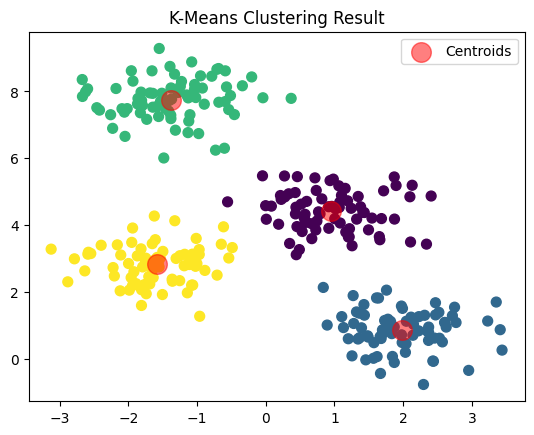

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Generate Synthetic Data
# We are creating 300 points clustered around 4 centers
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)  #change the random_state to see different clusters and centers to see different elbow plots

# 2. Implement K-Means
# HINT: Initialize the KMeans object with 4 clusters, then 'fit' it to X
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
kmeans.fit(X)

# 3. Get Predictions
# HINT: Use the .predict() method to assign each point to a cluster
labels = kmeans.predict(X)

# 4. Plotting (Provided)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5, label='Centroids')
plt.title("K-Means Clustering Result")
plt.legend()
plt.show()

In [ ]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Plot")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the Architecture
# HINT: Use models.Sequential() to create a stack of layers.
# We want: 
# - An input layer with 16 neurons (ReLU activation)
# - A hidden layer with 8 neurons (ReLU activation)
# - An output layer with 1 neuron (Sigmoid activation for binary classification)

model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
# 2. Compile the Model
# HINT: The 'optimizer' is the algorithm that updates weights (like Adam).
# The 'loss' function measures how wrong the model is.
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# 3. View the Architecture
# This shows how many "parameters" (weights) the model will learn.
model.summary()

print("If you see the model summary above, you've successfully built a Neural Network!")

ModuleNotFoundError: No module named 'tensorflow'

In [3]:
import torch
import torch.nn as nn

class ComplexNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=(64, 128, 64), output_dim=1):
        super().__init__()
        
        self.net = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Layer 2
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.BatchNorm1d(hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),

            # Output Layer
            nn.Linear(hidden_dims[2], output_dim)
        )

    def forward(self, x):
        return self.net(x)

# 1. Initialize model
complex_model = ComplexNet()

# 2. Create input batch
x_batch = torch.tensor(X[:16], dtype=torch.float32)

# 3. Forward pass
complex_output = complex_model(x_batch)

# 4. Check results
print(complex_model)
print("Output shape (should be 16, 1):", complex_output.shape)

ComplexNet(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)
Output shape (should be 16, 1): torch.Size([16, 1])


Training the PyTorch Neural Network...
Epoch 0: Loss 0.7080
Epoch 10: Loss 0.6541
Epoch 20: Loss 0.4987
Epoch 30: Loss 0.2676
Epoch 40: Loss 0.1026

Final Training Accuracy: 98.75%


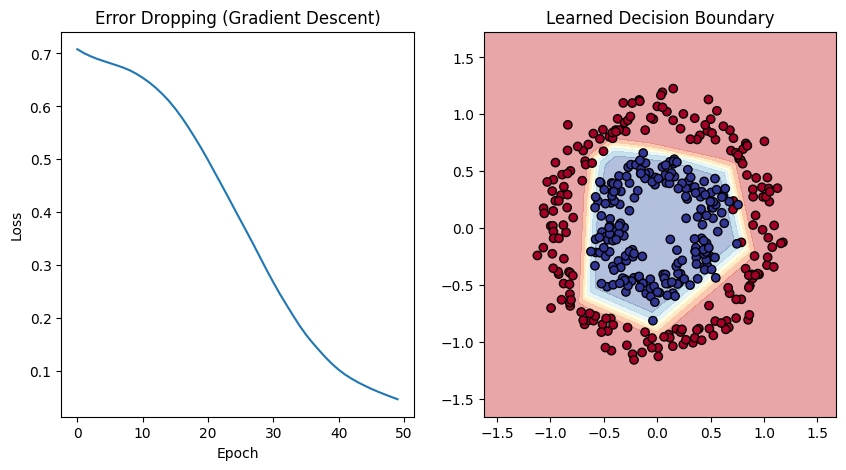

In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles

# 1. Generate Data
X_circles, y_circles = make_circles(n_samples=400, noise=0.1, factor=0.5, random_state=40)

# Convert to tensors
X_tensor = torch.tensor(X_circles, dtype=torch.float32)
y_tensor = torch.tensor(y_circles, dtype=torch.float32).unsqueeze(1)

# 2. Model
class CircleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

torch_model = CircleNet()

# 3. Optimizer + Loss
optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.03)
criterion = nn.BCELoss()

# 4. Training Loop
epochs = 50
losses = []

print("Training the PyTorch Neural Network...")
for epoch in range(epochs):
    torch_model.train()
    
    # Reset gradients
    optimizer.zero_grad()
    
    # Forward pass
    y_pred = torch_model(X_tensor)
    
    # Loss
    loss = criterion(y_pred, y_tensor)
    
    # Backprop
    loss.backward()
    
    # Update
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.4f}")

# 5. Accuracy
with torch.no_grad():
    preds = (torch_model(X_tensor) >= 0.5).float()
    accuracy = (preds == y_tensor).float().mean()
    print(f"\nFinal Training Accuracy: {accuracy.item() * 100:.2f}%")

# 6. Visualization
torch_model.eval()
with torch.no_grad():
    x_min, x_max = X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5
    y_min, y_max = X_circles[:, 1].min() - 0.5, X_circles[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    Z = torch_model(grid).numpy().reshape(xx.shape)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Error Dropping (Gradient Descent)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='RdYlBu', edgecolors='k')
plt.title("Learned Decision Boundary")

plt.show()

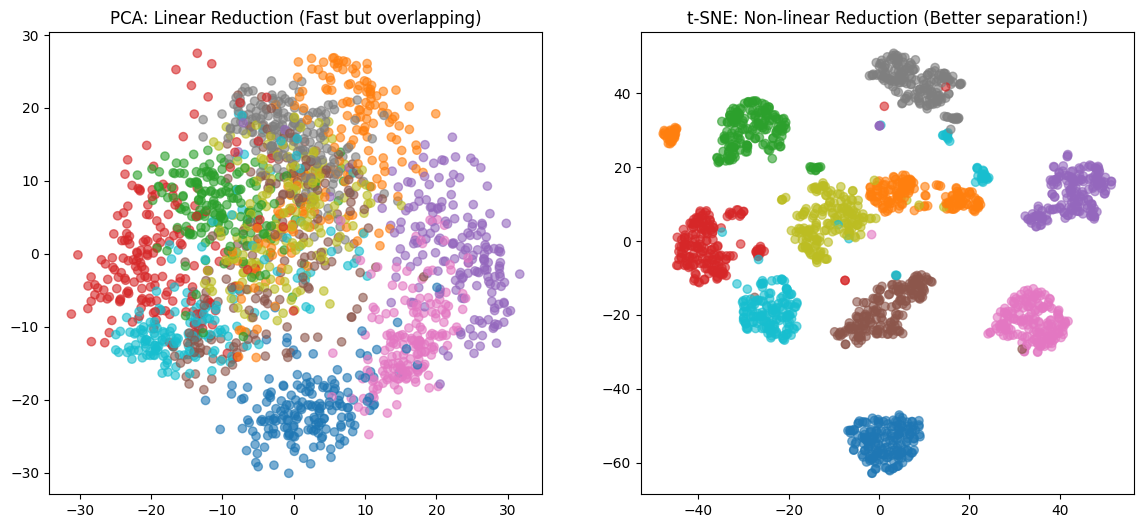

In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

digits = load_digits()
X, y = digits.data, digits.target

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.6)
ax1.set_title("PCA: Linear Reduction (Fast but overlapping)")

ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.6)
ax2.set_title("t-SNE: Non-linear Reduction (Better separation!)")

plt.show()

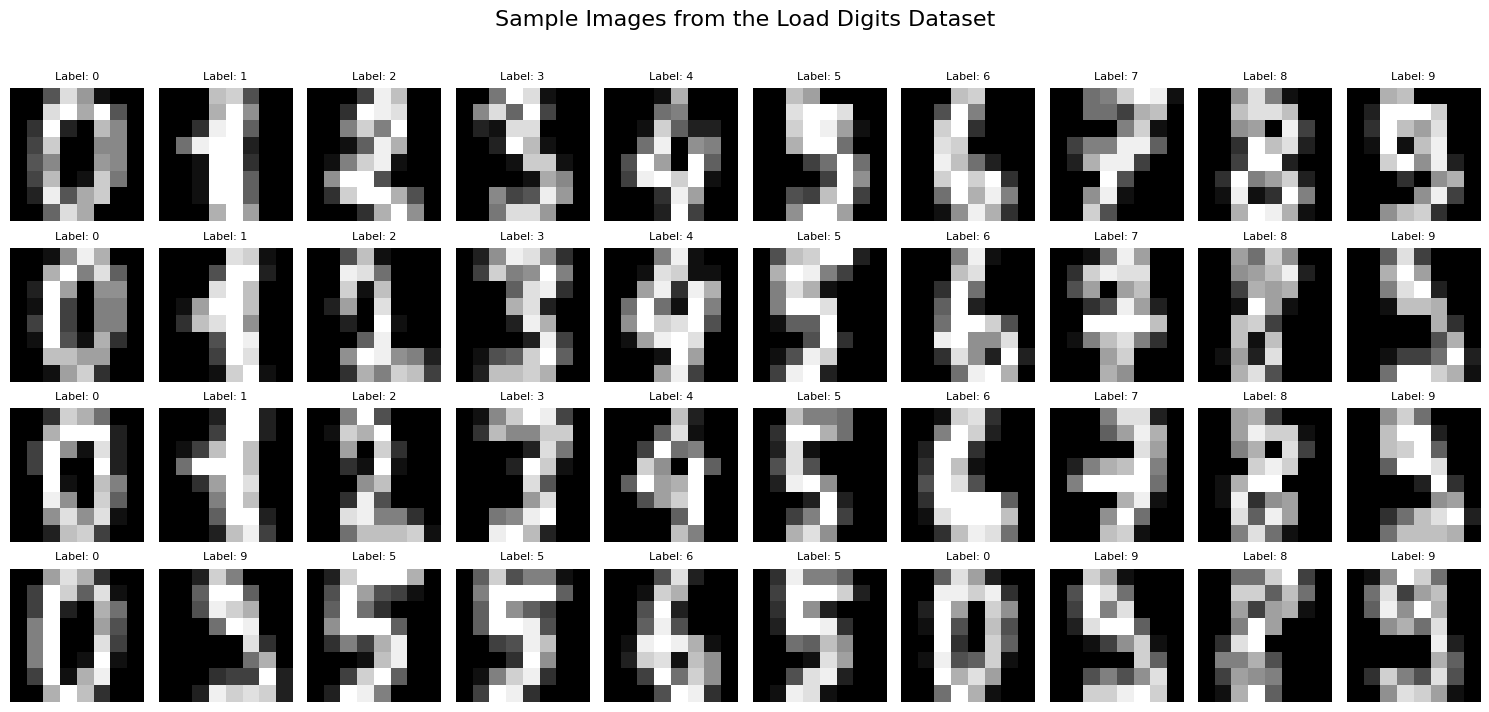

In [7]:
fig, axes = plt.subplots(4, 10, figsize=(15, 7))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}", fontsize=8)
    ax.axis('off')

plt.suptitle("Sample Images from the Load Digits Dataset", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 1. Image Preparation
img_array = np.zeros((128, 128), dtype=np.float32)
img_array[20:60, 20:60] = 1.0  # Square

rr, cc = np.ogrid[:128, :128]
circle_mask = (rr - 90)**2 + (cc - 90)**2 <= 25**2
img_array[circle_mask] = 1.0   # Circle

# Convert to tensor (Batch, Channel, H, W)
image_tensor = torch.tensor(img_array).unsqueeze(0).unsqueeze(0)

# 2. CNN Layer
edge_cnn = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=3, padding=1, bias=False)

# 3. Filters
sobel_x = torch.tensor([[[-1., 0., 1.],
                         [-2., 0., 2.],
                         [-1., 0., 1.]]])

sobel_y = torch.tensor([[[-1., -2., -1.],
                         [ 0.,  0.,  0.],
                         [ 1.,  2.,  1.]]])

laplacian = torch.tensor([[[ 0., -1.,  0.],
                           [-1.,  4., -1.],
                           [ 0., -1.,  0.]]])

# Load filters into CNN
edge_cnn.weight.data = torch.stack([sobel_x, sobel_y, laplacian], dim=0)

# 4. Forward pass
with torch.no_grad():
    feature_maps = edge_cnn(image_tensor)

# 5. Edge magnitude
sobel_x_out = feature_maps[0, 0].numpy()
sobel_y_out = feature_maps[0, 1].numpy()

sobel_mag = np.sqrt(sobel_x_out**2 + sobel_y_out**2)

# 6. Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original")

axes[1].imshow(feature_maps[0, 2].numpy(), cmap='hot')
axes[1].set_title("Laplacian (All Edges)")

axes[2].imshow(sobel_mag, cmap='hot')
axes[2].set_title("Combined Sobel (Boundaries)")

plt.show()

NameError: name 'img_array' is not defined

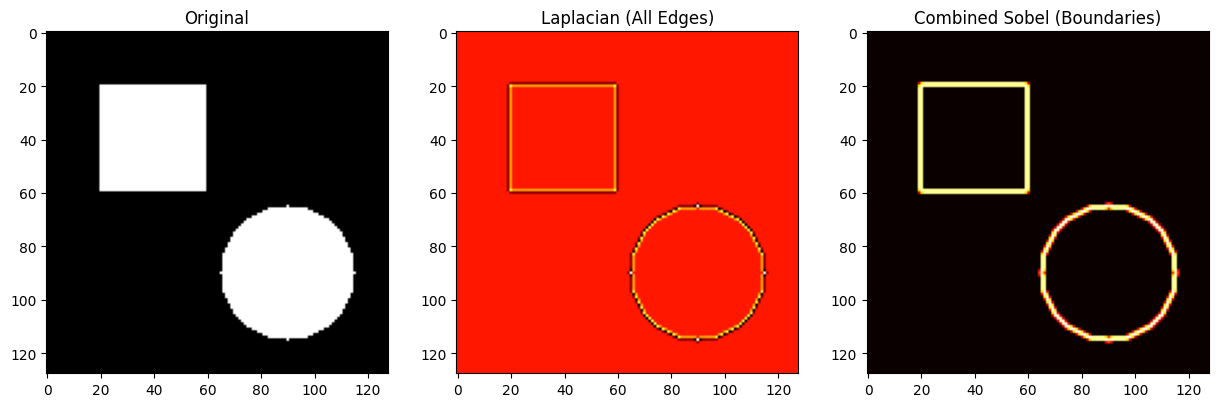

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 1. Image Preparation
img_array = np.zeros((128, 128), dtype=np.float32)
img_array[20:60, 20:60] = 1.0  # Square

rr, cc = np.ogrid[:128, :128]
circle_mask = (rr - 90)**2 + (cc - 90)**2 <= 25**2
img_array[circle_mask] = 1.0   # Circle

# Convert to tensor (Batch, Channel, H, W)
image_tensor = torch.tensor(img_array).unsqueeze(0).unsqueeze(0)

# 2. CNN Layer
edge_cnn = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=3, padding=1, bias=False)

# 3. Filters
sobel_x = torch.tensor([[[-1., 0., 1.],
                         [-2., 0., 2.],
                         [-1., 0., 1.]]])

sobel_y = torch.tensor([[[-1., -2., -1.],
                         [ 0.,  0.,  0.],
                         [ 1.,  2.,  1.]]])

laplacian = torch.tensor([[[ 0., -1.,  0.],
                           [-1.,  4., -1.],
                           [ 0., -1.,  0.]]])

# Load filters into CNN
edge_cnn.weight.data = torch.stack([sobel_x, sobel_y, laplacian], dim=0)

# 4. Forward pass
with torch.no_grad():
    feature_maps = edge_cnn(image_tensor)

# 5. Edge magnitude
sobel_x_out = feature_maps[0, 0].numpy()
sobel_y_out = feature_maps[0, 1].numpy()

sobel_mag = np.sqrt(sobel_x_out**2 + sobel_y_out**2)

# 6. Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original")

axes[1].imshow(feature_maps[0, 2].numpy(), cmap='hot')
axes[1].set_title("Laplacian (All Edges)")

axes[2].imshow(sobel_mag, cmap='hot')
axes[2].set_title("Combined Sobel (Boundaries)")

plt.show()